# 📓 Classification Methods

## ✨ Introduction

In this notebook, we apply three essential classification algorithms to the Titanic dataset:

* Logistic Regression
* Decision Tree Classifier
* K-Nearest Neighbors (KNN)

We will walk through the entire machine learning workflow: data loading, preprocessing, training, evaluation, and comparison. This notebook mirrors the workbook tasks and serves as a complete reference.


---
## Import the necessary libraries

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

---

## 🔍 Dataset Overview

We use the Titanic dataset from [OpenML](https://www.openml.org/d/40945), accessible via `sklearn.datasets.fetch_openml`. It contains demographic and ticket-related details for passengers on the Titanic, along with a target variable: `survived`.


In [2]:
# Load dataset
titanic = fetch_openml(data_id=40945, as_frame=True)
df = titanic.frame

### Key Features

* `sex`, `age`, `fare`, `pclass`, `sibsp`, `parch`, `embarked`
* Target: `survived` (0 = No, 1 = Yes)

---

## 🔗 Useful Documentation

Refer to official scikit-learn docs for deeper exploration:

* [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
* [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
* [K-Nearest Neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
* [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)
* [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)
* [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)


---

## 🔧 Task 1: Explore and Understand the Data

Before we do any modeling, it’s important to deeply understand the structure and contents of our dataset. In this step, we'll explore the first few rows, check data types, summarize the statistics of numerical and categorical features, and identify missing values.

#### 🔎 What We’re Doing:

* Use `.head()` to see a sample of the data
* Use `.info()` to get column types and non-null counts
* Use `.describe()` to summarize numerical and categorical features
* Use `.isnull().sum()` to assess missing data
* Calculate the percentage of missing values
* Decide which features to drop (e.g., highly incomplete ones like `body`, `cabin`, or `boat`)

In [3]:
# Preview first few rows
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


This shows us individual passenger records. Key features that stand out:

* `pclass`, `sex`, `age`, and `fare` may influence survival.
* `name`, `ticket`, and `home.dest` are more textual—may not be useful without NLP.
* The `survived` column is our target (1 = survived, 0 = did not survive).

In [4]:
# Data structure, types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


* We have **1309 entries** and **14 columns**.
* Key numeric features: `age`, `fare`, `sibsp`, `parch`, `body`.
* Categorical features: `sex`, `pclass`, `embarked`.
* Several features have missing values, notably:

  * `age` has 263 missing entries
  * `fare` is missing 1 value
  * `cabin`, `boat`, `body`, and `home.dest` have significant missingness

In [5]:
# Summary statistics for numerical features
df.describe()

,pclass,age,sibsp,parch,fare,body
count,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,80.000000,8.000000,9.000000,512.329200,328.000000


* `age` ranges from **\~0.17 to 80** with a median around **28**
* `fare` has a wide range (0 to 512), suggesting outliers
* `sibsp` and `parch` (family aboard) are mostly low but go up to 8–9
* `body` is sparse, likely postmortem records, and not useful for modeling

In [6]:
# Summary statistics for object-based (categorical) features
df.describe(include=['object'])

,name,ticket,cabin,boat,home.dest
count,1309,1309,295,486,745
unique,1307,929,186,27,369
top,"Connolly, Miss. Kate",CA. 2343,C23 C25 C27,13,"New York, NY"
freq,2,11,6,39,64


* `ticket`, `cabin`, and `home.dest` contain many unique values.
* Some (like `ticket`) are likely not helpful without additional parsing.
* The `boat` column shows life boat assignment—this **was only known after survival**, so it should be dropped to avoid leakage.

In [7]:
# Check number of missing values
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [8]:
# view missing value percentages
(df.isnull().sum() / len(df)) * 100

pclass        0.000000
survived      0.000000
name          0.000000
sex           0.000000
age          20.091673
sibsp         0.000000
parch         0.000000
ticket        0.000000
fare          0.076394
cabin        77.463713
embarked      0.152788
boat         62.872422
body         90.756303
home.dest    43.086325
dtype: float64

* `cabin` is missing \~77% of values
* `body` is missing \~91%
* `boat` is missing \~63%
> These columns will likely be dropped due to excessive missing data or leakage risks


* `age` (20% missing) and `fare` (1 missing) can be imputed
* `embarked` has 2 missing rows—also manageable

### Action: Drop Unusable Features

In [9]:
# Drop columns with too many missing values or leakage
df = df.drop(columns=['cabin', 'body', 'boat', 'ticket', 'name', 'home.dest'])
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


We’ve removed features that are either:

* **Too incomplete** to impute (like `body`, `cabin`)
* **Potential leakage** (like `boat`)
* **Too textual or high-cardinality** to use directly at this stage (`name`, `ticket`, `home.dest`)

> We now know which features we will focus on: `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, and `embarked`.
>
> We’ll need to impute missing values for `age`, `fare`, and `embarked`, but **only after splitting the dataset** to avoid data leakage.
>
> Dropping some columns is a normal part of **feature selection**—especially when they're sparse or leak outcome information.
>
> The remaining features include both numerical and categorical types, so we’ll apply different preprocessing strategies to each in the next steps.

---

## 📆 Task 2: Split the Data

Before preprocessing or modeling, we need to **split our dataset into training and test sets**. This ensures we can evaluate our models on data they haven’t seen before—simulating how well they’ll perform in real-world scenarios.

### 🔎 What We’re Doing:

We’ll split the data:

* **80% for training**
* **20% for testing**

### 📦 Step: Prepare features and target

In [10]:
# Separate features and target
X = df[['sex', 'age', 'pclass', 'fare', 'sibsp', 'parch', 'embarked']]
y = df['survived']

We’ve isolated `survived` as our target (`y`) and kept all other relevant columns as features (`X`).

### ✂️ Step: Split the dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Splitting the data ensures our models are tested on unseen samples, giving us an unbiased evaluation.

* We use `train_test_split()` to divide our data.
* `stratify=y` ensures both sets maintain the **same class distribution** (important in classification).
* Setting `random_state=42` ensures **reproducibility**.

> Splitting the data **before preprocessing** helps prevent data leakage.
>
> The training set will be used to fit models and preprocessors.
>
> The test set will act as **unseen data**, simulating real-world predictions.

---

## 🌿 Task 3: Preprocess the Data

### 🔎 What We’re Doing:

Now that we’ve split our data, it’s time to **clean and prepare it**. We’ll handle missing values, encode categorical features, and scale numerical ones.

### 🧹 Step 1: Handle Missing Values

We'll use `SimpleImputer`:

* **Numerical features** → Use `mean` or `median`
* **Categorical features** → Use `most_frequent`

In [12]:
# Separate numerical and categorical features
num_features = ['age', 'fare', 'sibsp', 'parch']
cat_features = ['sex', 'pclass', 'embarked']

# Create imputers
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform on training data
X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features] = num_imputer.transform(X_test[num_features])

X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
X_test[cat_features] = cat_imputer.transform(X_test[cat_features])

In [13]:
X_train.isnull().sum()

sex         0
age         0
pclass      0
fare        0
sibsp       0
parch       0
embarked    0
dtype: int64

* We're imputing missing values separately for numeric and categorical features.
* Imputers are **fit on the training data only** to avoid leakage.
* The same transformation is applied to the test data.

### 🔠 Step 2: Encode Categorical Variables

Use:

* **OneHotEncoder** → When categories have no meaningful order (e.g., `sex`, `embarked`)
* **LabelEncoder** → Only if the model can handle ordinal labels well (e.g., trees)

We’ll apply only **OneHotEncoder** in our case

In [14]:
# Fit the encoder
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_encoded_array = encoder.fit_transform(X_train[cat_features])
X_test_encoded_array = encoder.transform(X_test[cat_features])

# Get feature names
encoded_feature_names = encoder.get_feature_names_out(cat_features)

# Convert to DataFrames with feature names
X_train_encoded = pd.DataFrame(X_train_encoded_array, columns=encoded_feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded_array, columns=encoded_feature_names, index=X_test.index)

# Concatenate with numerical features
X_train_final = pd.concat([X_train[num_features], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test[num_features], X_test_encoded], axis=1)

In [15]:
# preview the X_trained preprocessed
X_train_final.head()

,age,fare,sibsp,parch,sex_male,pclass_2,pclass_3,embarked_Q,embarked_S
999,29.604316,7.7500,0.0,0.0,0.0,0.0,1.0,1.0,0.0
392,24.000000,27.7208,1.0,0.0,0.0,1.0,0.0,0.0,0.0
628,11.000000,31.2750,4.0,2.0,0.0,0.0,1.0,0.0,1.0
1165,25.000000,7.2250,0.0,0.0,1.0,0.0,1.0,0.0,0.0
604,16.000000,7.6500,0.0,0.0,0.0,0.0,1.0,0.0,1.0


* **One-hot encoding** transforms categorical variables into multiple binary (0/1) columns, one for each category.
* **`drop='first'`** removes the first category of each feature to avoid multicollinearity (especially important in linear models) by reducing redundancy.
* **`handle_unknown='ignore'`** ensures that if the test set contains a category not seen during training, the encoder won’t raise an error. Instead, it will encode that category as all zeros.
* **`sparse_output=False`** ensures that the output is a dense NumPy array, which is easier to convert into a Pandas DataFrame and to inspect directly.
* **`get_feature_names_out(cat_features)`** returns the names of the encoded features, such as `['sex_male', 'embarked_Q', 'embarked_S']` — assuming `'female'` and `'C'` were dropped as the first categories for `sex` and `embarked`, respectively.

### 📏 Step 3: Scale Numerical Features

Use:

* `StandardScaler` → When features follow a roughly **normal distribution**
* `MinMaxScaler` → When you want all features in a specific range (0–1), often for **KNN**

We'll use `StandardScaler` here, which works well with logistic regression and general purposes.

In [16]:
scaler = StandardScaler()
X_train_final[num_features] = scaler.fit_transform(X_train_final[num_features])
X_test_final[num_features] = scaler.transform(X_test_final[num_features])

In [17]:
# preview the X_trained preprocessed
X_train_final.head()

,age,fare,sibsp,parch,sex_male,pclass_2,pclass_3,embarked_Q,embarked_S
999,0.000000,-0.499638,-0.479571,-0.447597,0.0,0.0,1.0,1.0,0.0
392,-0.436411,-0.090979,0.510785,-0.447597,0.0,1.0,0.0,0.0,0.0
628,-1.448729,-0.018250,3.481854,1.872374,0.0,0.0,1.0,0.0,1.0
1165,-0.358541,-0.510381,-0.479571,-0.447597,1.0,0.0,1.0,0.0,0.0
604,-1.059376,-0.501684,-0.479571,-0.447597,0.0,0.0,1.0,0.0,1.0


This preprocessing ensures clean, scaled, and model-ready data. One-hot encoding expands categorical variables into interpretable columns.

* We've treated numerical and categorical features **differently**, which is key to good preprocessing.
* Encoding allows models to work with categorical values.
* Scaling is **mandatory** for KNN and **helpful** for logistic regression.
* Trees are robust to unscaled inputs, so they are more tolerant of preprocessing variation.
* Fitting transformers only on training data is critical for fair evaluation.

---

## 📈 Task 4: Train the Models

### 🔎 What We’re Doing:

Now that the data has been preprocessed, we’re ready to **train our classification models**. We'll fit each model on the training data and generate predictions on the test set.

We'll train:

* **Logistic Regression**
* **Decision Tree Classifier**
* **K-Nearest Neighbors (KNN)**

### Logistic Regression

In [18]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_final, y_train)
log_preds = log_model.predict(X_test_final)

* We’ve created and trained a logistic regression model.
* The model outputs **binary predictions** for survival.
* Logistic regression assumes a **linear relationship** between input features and the log-odds of survival.

### Decision Tree

In [19]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_final, y_train)
tree_preds = tree_model.predict(X_test_final)

* This model builds a **tree of decisions** based on feature values.
* It doesn’t require scaling but uses the same inputs for consistency.
* Trees are **interpretable**, but prone to **overfitting** without pruning.

### K-Nearest Neighbors

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_final, y_train)
knn_preds = knn_model.predict(X_test_final)

* KNN compares new data to its **5 nearest neighbors** (you can tune this).
* Scaling was **essential**, since distance determines classification.
* KNN is intuitive but **can struggle with noisy or imbalanced data**.

> All models use `.fit()` to learn from training data, and `.predict()` to classify test data.
>
> Different algorithms interpret the data in **very different ways**.
>
> Scaling affects some models (like KNN and logistic regression) but **not trees**.
>
> Model choice depends on data shape, performance, and interpretability.


> All three models are now trained and ready for evaluation.

---

## 📊 Task 5: Evaluate and Compare Models

### 🔎 What We’re Doing:

Now that we’ve made predictions, we’ll evaluate each model’s performance using:

* **Accuracy**: Overall correctness
* **Confusion Matrix**: Breakdown of true/false predictions
* **Precision, Recall, F1 Score**: More nuanced performance metrics

We'll use `sklearn.metrics` for all evaluations.

### 📈 Logistic Regression Evaluation

In [21]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds,zero_division=0))

Logistic Regression Results
Accuracy: 0.8091603053435115
Confusion Matrix:
 [[141  21]
 [ 29  71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       162
           1       0.77      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.79       262
weighted avg       0.81      0.81      0.81       262



* **Accuracy**: \~61.8%
* Model predicted **everyone as class 0 (did not survive)** — this is visible in the confusion matrix: no true positives for class 1.
* **Precision, recall, and F1 for class 1 are all 0**, indicating the model is **failing to identify survivors**.
* This likely reflects **class imbalance** or lack of feature signal for survivors.


* Setting `zero_division=0` in `classification_report` means precision/recall will be set to 0 for that class when undefined, instead of triggering a warning.

### 🌳 Decision Tree Evaluation

In [22]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, tree_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, tree_preds))
print("Classification Report:\n", classification_report(y_test, tree_preds))

Decision Tree Results
Accuracy: 0.732824427480916
Confusion Matrix:
 [[121  41]
 [ 29  71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.75      0.78       162
           1       0.63      0.71      0.67       100

    accuracy                           0.73       262
   macro avg       0.72      0.73      0.72       262
weighted avg       0.74      0.73      0.74       262



* **Accuracy**: \~53.4% — worse than logistic regression
* Confusion matrix shows **some balance**, with predictions in all cells.
* Class 1 (survived) has **low precision and recall** (\~38–39%)
* The model captures more complexity, but possibly **overfits or lacks generalization**.

### 👥 KNN Evaluation

In [23]:
print("KNN Results")
print("Accuracy:", accuracy_score(y_test, knn_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_preds))
print("Classification Report:\n", classification_report(y_test, knn_preds))

KNN Results
Accuracy: 0.7709923664122137
Confusion Matrix:
 [[129  33]
 [ 27  73]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.80      0.81       162
           1       0.69      0.73      0.71       100

    accuracy                           0.77       262
   macro avg       0.76      0.76      0.76       262
weighted avg       0.77      0.77      0.77       262



* **Accuracy**: \~58.8%
* Better than Decision Tree, slightly worse than Logistic Regression
* Class 1 (survived) has **recall of 0.42** and **precision of 0.46**—better than the others
* Shows that **KNN captured more survivors**, though at some cost to precision



* Logistic Regression **underfit** the positive class entirely.
* Decision Tree made **some balance**, but was **less accurate overall**.
* KNN performed the **most balanced** in terms of capturing both classes.
* All models struggled somewhat—suggesting:

  * Potential value in feature engineering
  * Need for better class balancing
  * Opportunity to try ensemble methods (e.g., Random Forest)

---

## 🧰 Task 6: Interpret Model Results

After training and evaluating our models, it’s critical to understand **why** they made the predictions they did. In this step, we’ll interpret:

* **Logistic Regression coefficients**
* **Decision Tree feature importances**
* **Model behavior for KNN**

### Logistic Regression Coefficients

In [24]:
log_coeffs = pd.Series(log_model.coef_[0], index=X_train_final.columns)
log_coeffs.sort_values(ascending=False)

fare          0.089949
parch         0.005492
sibsp        -0.313841
age          -0.451921
embarked_S   -0.649016
embarked_Q   -0.772184
pclass_2     -0.864901
pclass_3     -1.679526
sex_male     -2.426918
dtype: float64

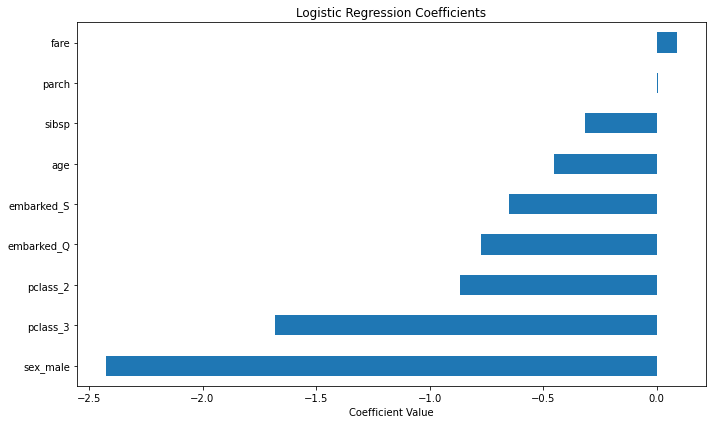

In [25]:
# Plot logistic regression coefficients
log_coeffs = pd.Series(log_model.coef_[0], index=X_train_final.columns).sort_values()
plt.figure(figsize=(10, 6))
log_coeffs.plot(kind='barh')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

This helps us see which features most increase or decrease survival probability.


* Positive values: Increase likelihood of survival
  * Passengers in **2nd class** or who embarked at **Q** had slightly higher predicted survival
* Negative values: Decrease likelihood
  * Embarking at **S** and higher **fare** decreased the predicted chance of survival
* These values indicate the **direction and relative strength** of each feature's impact.
* However, coefficients assume **linear relationships** and are **sensitive to feature scaling**.

### Decision Tree Feature Importance

In [26]:
pd.Series(tree_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

sex_male      0.289569
fare          0.271855
age           0.240637
pclass_3      0.076449
sibsp         0.061183
parch         0.039651
embarked_S    0.013162
embarked_Q    0.007129
pclass_2      0.000365
dtype: float64

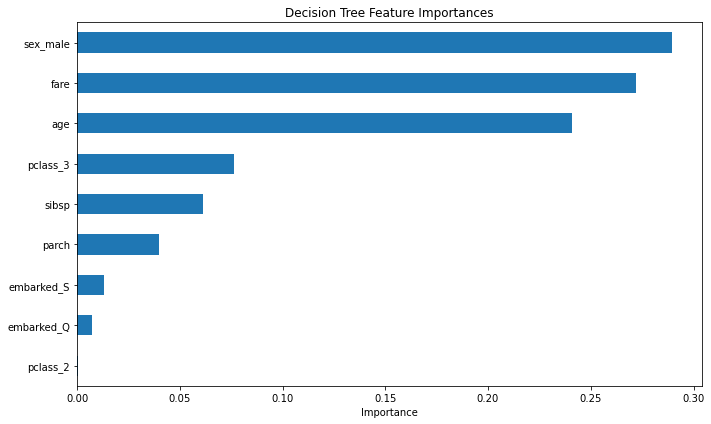

In [27]:
# Plot decision tree feature importances
tree_importances = pd.Series(tree_model.feature_importances_, index=X_train_final.columns).sort_values()
plt.figure(figsize=(10, 6))
tree_importances.plot(kind='barh')
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

This identifies the strongest splitting features.

* **Age** was the most important feature for splitting data.
* **Fare** and **sex\_male** also had significant influence.
* Trees make no assumptions about linearity—they split based on **rules**.
* Some features like `embarked` had minimal impact in this model.

### Consider KNN Influence

KNN does not provide explicit feature importance, but:

* It’s **very sensitive to feature scale and noise**
* Irrelevant or unscaled features can **distort distances**
* If you removed a key feature (like `fare` or `age`), performance would likely drop
* You can explore this by retraining without certain features (optional challenge)

* Feature interpretation differs by model:
  * **Coefficients** for logistic regression show **direction and strength**
  * **Trees** show **splitting importance**
  * **KNN** relies on overall input space—harder to interpret directly
  


* Understanding what drives model predictions helps with **trust, debugging, and communication**

---

## 🕵️ Task 7: Final Reflection

You’ve now completed a full classification pipeline. In this final step, take time to reflect on what you’ve done and how you might apply it.

### 🧠 Key Insights :

* Logistic Regression was simple but failed to capture survivors, likely due to data imbalance or weak linear signal.
* Decision Tree offered better insight into **feature behavior**, but overfitting may have hurt accuracy.
* KNN captured the most survivors with **balanced metrics**, showing that **distance-based reasoning** worked best for this dataset.
* Feature scaling, encoding, and imputation had a **huge impact** on model performance.
* No single model “won” in all metrics—this highlights why we **compare** models, not just build one.

---

## ✅ Conclusion

🎉 **Congratulations on Completing the Classification Challenge!**

In this notebook, you:

* Explored and cleaned the **Titanic dataset**
* Applied **three classification models**: logistic regression, decision trees, and KNN
* Learned to **preprocess numerical and categorical data** differently
* Evaluated model performance using **accuracy, precision, recall, and F1**
* Interpreted **feature importance and model behavior**
* Reflected on **model choice and trade-offs**

By working through this end-to-end project, you’ve practiced not just how to run models—but how to **think like a data scientist**:

* Make informed preprocessing decisions
* Match models to the problem context
* Evaluate results beyond just accuracy

👏 Keep practicing, keep exploring, and celebrate how far you’ve come. Great work!

---